# Ćwiczenia 12. Operacje na sekwencjach genetycznych w Biopythonie

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import gzip
from Bio import Seq
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord

## Ćwiczenie 1. 

Zaimportuj zestaw danych syntetic.fasta z użyciem pakietu Biopython. Zobacz jakie dane pojedynczej sekwencji możesz odczytać.

In [22]:
df = SeqIO.parse("data/syntetic.fasta","fasta")

In [23]:
seq1 = next(df)

In [24]:
seq1

SeqRecord(seq=Seq('GGGTATGCGTGACCGTGTTCCAGCCAATTCAAGTGCTAGTGGGGATGGACACAC...GGT'), id='0a723f666125d76d2406cc734bb075c8', name='0a723f666125d76d2406cc734bb075c8', description='0a723f666125d76d2406cc734bb075c8 | Loxodonta africana', dbxrefs=[])

## Ćwiczenie 2.

Dokonaj następujących operacji:
* wyznacz sekwencje komplementarne do zestawu danych i zapisz do pliku complementary.fa
* wykonaj transkrypcję na RNA każdej sekwencji z zestawu danych i zapisz do pliku RNA.fa
* wyznacz sekwencje komplementarne do wyznaczonych sekwencji RNA i zapisz do pliku complementary_RNA.fa

In [25]:
seq1.seq.complement() # seq komplementarne

Seq('CCCATACGCACTGGCACAAGGTCGGTTAAGTTCACGATCACCCCTACCTGTGTG...CCA')

In [26]:
list = [SeqRecord(seq.seq.complement(), description = seq.description, name = seq.name, id = seq.id) for seq in SeqIO.parse("data/syntetic.fasta","fasta") ]

In [27]:
SeqIO.write(list, "complementary.fa", "fasta")

134

In [28]:
seq1.seq.transcribe() # transkrypcja

Seq('GGGUAUGCGUGACCGUGUUCCAGCCAAUUCAAGUGCUAGUGGGGAUGGACACAC...GGU')

In [29]:
list2 = [SeqRecord(seq.seq.transcribe(), description = seq.description, name = seq.name, id = seq.id) for seq in SeqIO.parse("data/syntetic.fasta","fasta") ]

In [30]:
SeqIO.write(list2, "RNA.fa", "fasta")

134

In [33]:
list3 = [SeqRecord(seq.seq.complement(), description = seq.description, name = seq.name, id = seq.id) for seq in list2]

In [34]:
SeqIO.write(list3, "complementary_RNA.fa", "fasta")

134

## Ćwiczenie 3.

Przetłumacz sekwencje RNA na sekwencje białek i zapisz do pliku proteins.fa. Wykorzystaj tabelę dla mitochondrialnego RNA kręgowców (tabela numer 2) i zadbaj o to aby stop-codony nie były uwzględniane w sekwencji białek.

In [37]:
list2[0]

SeqRecord(seq=Seq('GGGUAUGCGUGACCGUGUUCCAGCCAAUUCAAGUGCUAGUGGGGAUGGACACAC...GGU'), id='0a723f666125d76d2406cc734bb075c8', name='0a723f666125d76d2406cc734bb075c8', description='0a723f666125d76d2406cc734bb075c8 | Loxodonta africana', dbxrefs=[])

In [ ]:
list2[0].translate() 
# oznaczenia białek, * to nierozpoznane trójki genów

SeqRecord(seq=Seq('GYA*PCSSQFKC*WGWTHGSISCRTNCIAVAEKLIVRSRNCYRIG*YRCQGMSS...CTG'), id='<unknown id>', name='<unknown name>', description='<unknown description>', dbxrefs=[])

In [ ]:
list2[0].translate(table=2)
# tabela 2 przeznaczona dla kregowcow, wiecej dopasowań (* mogą być stop)

SeqRecord(seq=Seq('GYAWPCSSQFKC*WGWTHGSMSCRTNCIAVAEKLIVRSRNCYRMG*YRCQGMSS...CTG'), id='<unknown id>', name='<unknown name>', description='<unknown description>', dbxrefs=[])

In [ ]:
list2[0].translate(table=2, to_stop=True)
# przetłumaczony fragment do kodonu stop

SeqRecord(seq=Seq('GYAWPCSSQFKC'), id='<unknown id>', name='<unknown name>', description='<unknown description>', dbxrefs=[])

In [42]:
list4 = [SeqRecord(seq.seq.translate(table=2, to_stop=True), description = seq.description, name = seq.name, id = seq.id) for seq in list2]

In [43]:
SeqIO.write(list4, "proteins.fa", "fasta")

134

## Ćwiczenie 4.

Najczęstszym zleceniem dla bioinformatyka jest określenie taksonomii w próbce. Oznacza to wyznaczenie nazw gatunków, których sekwencje zostały odnalezione. Jest to proces bardzo trudny z punktu widzenia złożoności obliczeniowej stąd trwa on bardzo długo. Istnieje wiele algorytmów do określenia gatunków z sekwencji jednak każdy z nich potrzebuje tzw. **bazy sekwencji referencyjnych**, która zawiera sekwencje wzorcowe gatunków przypisane do ich nazwy taksonomicznej. Algorytm porównuje sekwencje z próby do referencji i określa do jakiego gatunku sekwencja testowana jest najbardziej podobna. Najpopularniejszym algorytmem do klasyfikacji taksonomicznej jest BLAST. Wykonuje on tzw. *alignment* sekwencji testowanej z referencją i określa jak wiele nukleotydów się pokrywa. Na tej podstawie oblicza indeks podobieństwa sekwencji.

#### Zadanie

Wykorzystaj BLAST do odkrycia jaki organizm jest kodowany przez wybraną sekwencję.

In [ ]:
from Bio import Blast
# blast oblicza aligmnent (wstawia braki gdzie się nie pokrywają)

In [55]:
tax = Blast.qblast("blastn", "nt", seq1.seq) # algorytm, baza, seqwencja

In [56]:
for i in Blast.parse(tax):
    for j in i:
        print(j.target)

ID: gi|3146765826|emb|OZ404075.1|
Name: OZ404075
Description: Schizothorax curvilabiatus genome assembly, chromosome: 14
Number of features: 0
Undefined sequence of length 31894580


## Ćwiczenie 5.

Sekwencjonowanie nowej generacji opiera się na *odgadywaniu* nukletodyów w sekwencji na podstawie barwy odbitego od nich światła lasera. Sekwanator nie jest urządzeniem doskonałym a same nukleotydy nie zawsze świecą idealnie czystym światłem w określonym kolorze. Stąd pojawia się potrzeba korekcji błędów i badania jakości uzyskanego odczytu. Popularną metodą na określenie jakości odczytu jest skala PHRED, która jest logarytmicznym indeksem jakości, mówiącym o tym jak małe jest prawdopodobieństwo błędu odczytu nukleotydu. Każda tzw. baza w pliku FASTQ ma przypisaną liczbę **Q**. Ta liczba mówi jak bardzo sekwanator jest pewien tego, że baza jest odczytana poprawnie. Wartość **Q** wyrażona jest w następujący sposób:
$$Q=-10\cdot\log_{10}{(P_{error})}$$
gdzie $P_{error}$ to prawdopodobieństwo, że baza jest błędnie odczytana przez sekwanator.

Skalę PHRED należy rozumieć zgodnie z poniższą tabelą:
|Wartość **Q**|Prawdopodobieństwo błędu|Trafność|
|:-:|:-:|:-:|
|Q10|1 na 10 baz jest błędna|90%|
|Q20|1 na 100 baz jest błędna|99%|
|Q30|1 na 1000 baz jest błędna|99.9%|
|Q40|1 na 10000 baz jest błędna|99.99%|

Standardem dobrego odczytu jest Q30+.

#### Zadanie

Wczytaj plik `O_U1_W_COI_JJ_S9_L001_R1_001.fastq.gz` i narysuj wykres pudełkowy jakości wszystkich sekwencji w tym pliku. Opisz odpowiednio osie wykresu, nadaj mu tytuł. Ustal wartości na osi X od 1 do 250 ze skokiem co 10 oraz usuń wyświetlanie outlierów.

In [66]:
with gzip.open("data/O_U1_W_COI_JJ_S9_L001_R1_001.fastq.gz", "rt") as zip: #r - read only, t- text (.gzip otwiera w binarnym)
    fastq = SeqIO.parse(zip, "fastq")
    quality = [fasterq.letter_annotations["phred_quality"] for fasterq in fastq]

In [68]:
sonic = pd.DataFrame(quality)

<Axes: >

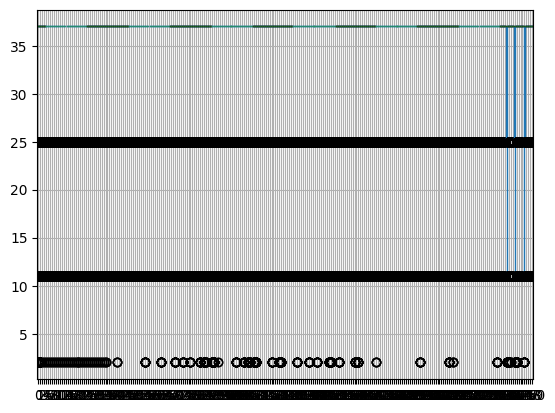

In [ ]:
sonic.boxplot() # słaby wykres, trzeba poprawić

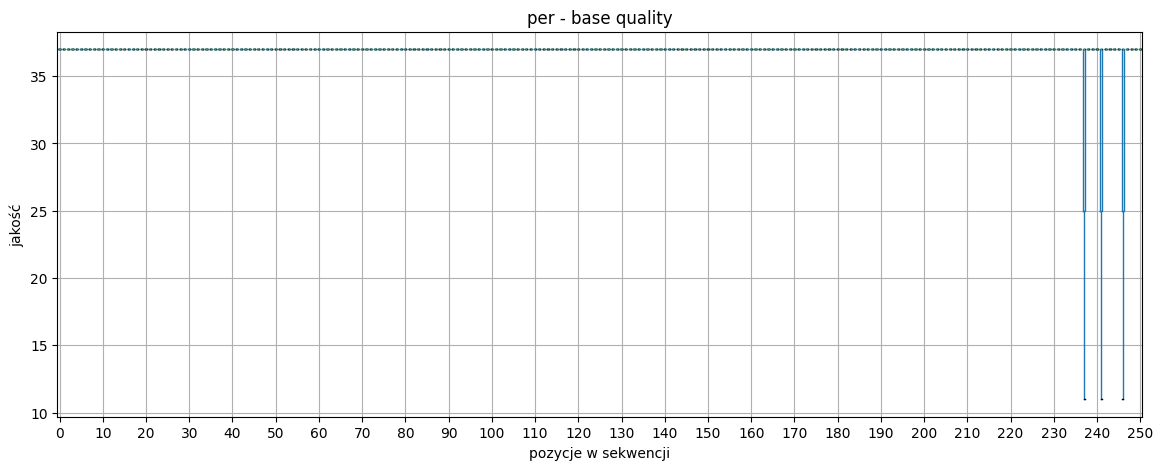

In [78]:
plt.figure(figsize=(14, 5))

sonic.boxplot(showfliers=False)
plt.xlabel("pozycje w sekwencji")
plt.ylabel("jakość")
plt.title("per - base quality")
plt.xticks(range(1, 252, 10)) # 252 trzeba bo step sie konczy wczesniej i nie pokaze całej skali

plt.show()